In [1]:
# Cell 1: Imports 
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from collections import deque
import sys
import time 


In [3]:
# Cell 2: HybridPowerFlowOptimizer Class

class HybridPowerFlowOptimizer:
    """
    Optimizes power flow using a hybrid metaheuristic approach, incorporating
    local search, adaptive algorithm selection, stagnation handling, and
    adaptive parameters. Allows zero-cost load shedding.
    """

    def __init__(self, A_matrix, line_limits, gen_costs, gen_limits_min, gen_limits_max, initial_B, memory_size=100):
        self.A = A_matrix
        self.line_limits = np.array(line_limits, dtype=np.float64)
        self.num_lines = A_matrix.shape[0]
        self.num_buses = A_matrix.shape[1]
        self.tolerance = 1e-6 
        
        
        self.initial_B = initial_B.copy().flatten()

        
        self.gen_indices = np.where(self.initial_B > self.tolerance)[0]
        self.load_indices = np.where(self.initial_B <= self.tolerance)[0]

        if len(self.gen_indices) == 0:
            raise ValueError("No generator buses identified (initial B > 0). Cannot proceed.")

        print(f"Identified {len(self.gen_indices)} generator buses (indices: {self.gen_indices})")
        print(f"Identified {len(self.load_indices)} load buses (indices: {self.load_indices}) - Load shedding enabled (Zero Cost).")

       
        flat_gc = np.array(gen_costs).flatten()
        flat_gmin = np.array(gen_limits_min).flatten()
        flat_gmax = np.array(gen_limits_max).flatten()
        if len(flat_gc) != self.num_buses or len(flat_gmin) != self.num_buses or len(flat_gmax) != self.num_buses:
            raise ValueError(f"Generator cost/limit array length mismatch (Expected {self.num_buses})")
        self.gen_costs_only = flat_gc[self.gen_indices]
        self.gen_limits_min_only = flat_gmin[self.gen_indices]
        self.gen_limits_max_only = flat_gmax[self.gen_indices]
        if np.any(self.gen_limits_max_only < self.gen_limits_min_only):
             raise ValueError("Generator Max limit cannot be less than Min limit.")


        
        self.initial_B_load_fixed = self.initial_B[self.load_indices]
        self.load_limits_min_only = self.initial_B_load_fixed 
        self.load_limits_max_only = np.zeros_like(self.load_limits_min_only) 

       
        needs_adjust = False
        
        initial_gen_values = self.initial_B[self.gen_indices]
        if np.any(initial_gen_values < self.gen_limits_min_only - self.tolerance) or \
           np.any(initial_gen_values > self.gen_limits_max_only + self.tolerance):
            print("Warning: Initial generator B outside limits. Clamping...")
            self.initial_B[self.gen_indices] = np.clip(initial_gen_values, self.gen_limits_min_only, self.gen_limits_max_only)
            needs_adjust = True

       
        required_total_injection = 0.0
        current_total_injection = np.sum(self.initial_B)
        difference_init = required_total_injection - current_total_injection
        num_gens = len(self.gen_indices)

        
        if abs(difference_init) > self.tolerance * self.num_buses:
            print(f"Warning: Initial injections sum to {current_total_injection:.4f} (≠ 0). Adjusting generators to balance...")
            if num_gens > 0:
                diff_per_gen_init = difference_init / num_gens
                
                adjusted_gens = self.initial_B[self.gen_indices] + diff_per_gen_init
                
                clipped_adjusted_gens = np.clip(adjusted_gens, self.gen_limits_min_only, self.gen_limits_max_only)
                
                actual_adjustment_applied = np.sum(clipped_adjusted_gens) - np.sum(self.initial_B[self.gen_indices])
                self.initial_B[self.gen_indices] = clipped_adjusted_gens

                
                remaining_diff = difference_init - actual_adjustment_applied
                if abs(remaining_diff) > self.tolerance * self.num_buses:
                     print(f"Warning: Could not fully balance initial state due to gen limits. Remaining imbalance: {remaining_diff:.4f}")
                needs_adjust = True
            else:
                
                print("ERROR: Cannot balance initial state - no generators identified.")
                needs_adjust = True 

        if needs_adjust:
            print("-> Adjusted initial B state used for optimization:", np.round(self.initial_B, 4))
        

        
        self.memory = deque(maxlen=memory_size)

        
        self.stagnation_threshold = 50 
        self.diversification_fraction = 0.2 #


    def _apply_constraints(self, solution_vector):
        """Applies generator/load limits and enforces power balance."""
        sol = solution_vector.copy().flatten()
        num_gens = len(self.gen_indices)
        num_loads = len(self.load_indices)

        
        if num_loads > 0:
            try:
                sol[self.load_indices] = np.clip(sol[self.load_indices], self.load_limits_min_only, self.load_limits_max_only)
            except IndexError:
                 print("Warning (_apply_constraints): Load index error.")
                 pass 

        
        if num_gens > 0:
            try:
                sol[self.gen_indices] = np.clip(sol[self.gen_indices], self.gen_limits_min_only, self.gen_limits_max_only)
            except IndexError:
                 print("Warning (_apply_constraints): Gen index error.")
                 pass 

        
        if num_gens > 0:
            current_load_sum = np.sum(sol[self.load_indices]) if num_loads > 0 else 0.0
            required_gen_sum = -current_load_sum 
            current_gen_sum = np.sum(sol[self.gen_indices])
            difference = required_gen_sum - current_gen_sum

            
            if abs(difference) > self.tolerance * self.num_buses:
                
                adjustment_per_gen = difference / num_gens
                adjusted_gens = sol[self.gen_indices] + adjustment_per_gen

                
                clipped_adjusted_gens = np.clip(adjusted_gens, self.gen_limits_min_only, self.gen_limits_max_only)

                
                actual_adjustment_applied = np.sum(clipped_adjusted_gens) - current_gen_sum
                remaining_diff = difference - actual_adjustment_applied

                sol[self.gen_indices] = clipped_adjusted_gens

                
                if abs(remaining_diff) > self.tolerance * self.num_buses * 10: 
                     
                     pass
                     

        return sol.reshape(-1, 1)


    def _calculate_fitness(self, solution):
        """Calculates fitness: Penalties & Deviation(High) + GenCost(Low)."""
        sol_flat = solution.flatten()
        if not np.all(np.isfinite(sol_flat)): return np.inf

        
        try:
            C = np.dot(self.A, sol_flat)
            if not np.all(np.isfinite(C)): return np.inf
            flows = C.flatten()
        except ValueError:
            return np.inf 

        
        penalty_multiplier = 1e10 

        
        line_violations = np.maximum(0, np.abs(flows) - (self.line_limits + self.tolerance))
        line_violation_penalty = penalty_multiplier * np.sum(line_violations**2)

        
        gen_limit_penalty = 0.0
        if len(self.gen_indices) > 0:
            gen_values = sol_flat[self.gen_indices]
            violations_lower_g = np.maximum(0, self.gen_limits_min_only - gen_values + self.tolerance)
            violations_upper_g = np.maximum(0, gen_values - self.gen_limits_max_only - self.tolerance)
            gen_limit_penalty = penalty_multiplier * (np.sum(violations_lower_g**2) + np.sum(violations_upper_g**2))

        
        load_limit_penalty = 0.0
        if len(self.load_indices) > 0:
            load_values = sol_flat[self.load_indices]
            
            violations_lower_l = np.maximum(0, self.load_limits_min_only - load_values + self.tolerance) 
            violations_upper_l = np.maximum(0, load_values - self.load_limits_max_only - self.tolerance) 
            load_limit_penalty = penalty_multiplier * (np.sum(violations_lower_l**2) + np.sum(violations_upper_l**2))

        
        balance_violation = abs(np.sum(sol_flat))
        
        balance_penalty = penalty_multiplier * (balance_violation**2) if balance_violation > self.tolerance * self.num_buses else 0.0

        
        generator_deviation = self._get_generator_deviation(solution)
        deviation_penalty_component = 1e5 * generator_deviation 

        
        gen_rescheduling_cost = self._get_rescheduling_cost(solution)
        gen_cost_weight = 0.1

        
        fitness = (line_violation_penalty
                   + gen_limit_penalty
                   + load_limit_penalty
                   + balance_penalty
                   + deviation_penalty_component
                   + gen_cost_weight * gen_rescheduling_cost
                  )

        
        return fitness if np.isfinite(fitness) else np.inf

    def _is_feasible(self, solution, verbose=False):
        """Checks if a solution meets all hard constraints within tolerance."""
        if solution is None:
            if verbose: print("DEBUG (_is_feasible): Input solution is None.")
            return False
        sol_flat = solution.flatten()
        if not np.all(np.isfinite(sol_flat)):
            if verbose: print("DEBUG (_is_feasible): Solution contains non-finite values.")
            return False

        
        line_ok = False
        flows = np.array([]) 
        try:
            C = np.dot(self.A, sol_flat)
            if not np.all(np.isfinite(C)): raise ValueError("Flows NaN/Inf")
            flows = C.flatten()
            line_ok = np.all(np.abs(flows) <= self.line_limits + self.tolerance)
        except Exception as e:
            line_ok = False
            if verbose: print(f"DEBUG: Line check error: {e}")

        
        gen_ok = False
        gen_values = sol_flat[self.gen_indices] if len(self.gen_indices) > 0 else np.array([])
        if len(gen_values) == len(self.gen_limits_min_only): 
            gen_ok = np.all(gen_values >= self.gen_limits_min_only - self.tolerance) and \
                     np.all(gen_values <= self.gen_limits_max_only + self.tolerance)
        elif len(self.gen_indices) == 0: 
             gen_ok = True 

        
        load_ok = False
        load_values = sol_flat[self.load_indices] if len(self.load_indices) > 0 else np.array([])
        if len(load_values) == len(self.load_limits_min_only):
            load_ok = np.all(load_values <= self.load_limits_max_only + self.tolerance) and \
                      np.all(load_values >= self.load_limits_min_only - self.tolerance)
        elif len(self.load_indices) == 0: 
             load_ok = True 

        
        bal_ok = abs(np.sum(sol_flat)) < self.tolerance * self.num_buses

        
        feasible = line_ok and gen_ok and load_ok and bal_ok

        
        if verbose or not feasible:
            print(f"--- Feasibility Check {'FAILED' if not feasible else 'PASSED'} ---")
            
            if not line_ok:
                failing_lines = np.where(np.abs(flows) > self.line_limits + self.tolerance)[0]
                print(f"  Line constraints failed. Failing lines: {failing_lines+1}")
                for idx in failing_lines[:5]: # Show first 5 violations
                     if idx < len(flows) and idx < len(self.line_limits):
                          print(f"    Line {idx+1}: Flow={abs(flows[idx]):.4f}, Limit={self.line_limits[idx]:.4f}")
                     else: print(f"    Line {idx+1}: Index out of bounds for details.")
            else: print("  Line constraints met.")
            
            if not gen_ok:
                if len(gen_values) == len(self.gen_limits_min_only):
                    failing_min_g = np.where(gen_values < self.gen_limits_min_only - self.tolerance)[0]
                    failing_max_g = np.where(gen_values > self.gen_limits_max_only + self.tolerance)[0]
                    if len(failing_min_g) > 0: print(f"  Gen Bus {self.gen_indices[failing_min_g[0]]+1} violated MIN Limit ({gen_values[failing_min_g[0]]:.3f} < {self.gen_limits_min_only[failing_min_g[0]]:.3f})")
                    elif len(failing_max_g) > 0: print(f"  Gen Bus {self.gen_indices[failing_max_g[0]]+1} violated MAX Limit ({gen_values[failing_max_g[0]]:.3f} > {self.gen_limits_max_only[failing_max_g[0]]:.3f})")
                    else: print("  Generator limits failed (Unknown reason).") 
                else: print(f"  Generator limits failed (Dimension mismatch: Expected {len(self.gen_limits_min_only)}, Got {len(gen_values)}).")
            else: print("  Generator limits met.")
            
            if not load_ok:
                 if len(load_values) == len(self.load_limits_min_only):
                    failing_min_l = np.where(load_values < self.load_limits_min_only - self.tolerance)[0]
                    failing_max_l = np.where(load_values > self.load_limits_max_only + self.tolerance)[0]
                    if len(failing_min_l)>0: print(f"  Load Bus {self.load_indices[failing_min_l[0]]+1} violated MIN Limit ({load_values[failing_min_l[0]]:.3f} < {self.load_limits_min_only[failing_min_l[0]]:.3f})")
                    elif len(failing_max_l)>0: print(f"  Load Bus {self.load_indices[failing_max_l[0]]+1} violated MAX Limit ({load_values[failing_max_l[0]]:.3f} > {self.load_limits_max_only[failing_max_l[0]]:.3f})")
                    else: print("  Load limits failed (Unknown reason).")
                 else: print(f"  Load limits failed (Dimension mismatch: Expected {len(self.load_limits_min_only)}, Got {len(load_values)}).")
            else: print("  Load limits met.")
            
            if not bal_ok: print(f"  Power balance check failed, sum={np.sum(sol_flat):.8f}")
            else: print("  Power balance met.")
            print("-" * 40)
        return feasible

    def _get_generator_deviation(self, solution):
        """Calculates sum of absolute changes for generators."""
        sol_flat = solution.flatten()
        if len(self.gen_indices) == 0: return 0.0
        try:
           
            if np.max(self.gen_indices) >= len(sol_flat) or np.max(self.gen_indices) >= len(self.initial_B):
                 print("Warning (_get_generator_deviation): Index out of bounds.")
                 return np.inf
            return np.sum(np.abs(sol_flat[self.gen_indices] - self.initial_B[self.gen_indices]))
        except IndexError:
            print("Warning (_get_generator_deviation): Index error during calculation.")
            return np.inf 

    def _get_rescheduling_cost(self, solution):
        """Calculates cost based on generator changes."""
        sol_flat = solution.flatten()
        if len(self.gen_indices) == 0: return 0.0 
        try:
            
            if len(self.gen_costs_only) != len(self.gen_indices) or \
               np.max(self.gen_indices) >= len(sol_flat) or \
               np.max(self.gen_indices) >= len(self.initial_B):
                 print("Warning (_get_rescheduling_cost): Index or dimension mismatch.")
                 return np.inf
            deviation = np.abs(sol_flat[self.gen_indices] - self.initial_B[self.gen_indices])
            cost = np.sum(self.gen_costs_only * deviation)
            return cost
        except IndexError:
            print("Warning (_get_rescheduling_cost): Index error during calculation.")
            return np.inf 


    def _generate_random_solution(self):
        """Generates a new random solution, perturbed around the initial state."""
        rand_sol = self.initial_B.copy()
        n_gens = len(self.gen_indices)
        n_loads = len(self.load_indices)

        
        if n_gens > 0:
            
            gen_range = np.maximum(self.tolerance, self.gen_limits_max_only - self.gen_limits_min_only)
            
            perturbation_factor = 0.2
            perturbations = (np.random.rand(n_gens) - 0.5) * gen_range * perturbation_factor
            rand_sol[self.gen_indices] = np.clip(self.initial_B[self.gen_indices] + perturbations,
                                                 self.gen_limits_min_only, self.gen_limits_max_only)

        
        if n_loads > 0:
            
            shedding_factor = 0.1
            
            potential_increase = np.random.rand(n_loads) * np.abs(self.initial_B[self.load_indices]) * shedding_factor
            rand_sol[self.load_indices] = np.clip(self.initial_B[self.load_indices] + potential_increase,
                                                  self.load_limits_min_only, self.load_limits_max_only) 

        
        return self._apply_constraints(rand_sol)


    def _apply_local_search(self, solution, iteration, max_iterations):
        """
        Applies a simple local search heuristic to refine a solution.
        Perturbs one variable slightly and keeps the change if fitness improves.
        """
        current_solution = solution.copy()
        current_fitness = self._calculate_fitness(current_solution)
        if not np.isfinite(current_fitness): return solution 

        
        progress_ratio = iteration / max_iterations
        
        step_scale_factor = 0.1 * (1.0 - progress_ratio) + 0.01 * progress_ratio

        
        num_attempts = min(5, int(np.sqrt(self.num_buses)))

        for _ in range(num_attempts):
            
            idx_to_perturb = random.randrange(self.num_buses)

            perturbed_solution = current_solution.copy()
            original_value = perturbed_solution[idx_to_perturb, 0]

            
            perturb_range = 1.0 
            if idx_to_perturb in self.gen_indices:
                gen_idx_local = np.where(self.gen_indices == idx_to_perturb)[0][0]
                gen_op_range = self.gen_limits_max_only[gen_idx_local] - self.gen_limits_min_only[gen_idx_local]
                perturb_range = max(self.tolerance, gen_op_range) * step_scale_factor
            elif idx_to_perturb in self.load_indices:
                load_idx_local = np.where(self.load_indices == idx_to_perturb)[0][0]
                
                load_op_range = 0.0 - self.load_limits_min_only[load_idx_local] 
                perturb_range = max(self.tolerance, load_op_range) * step_scale_factor

            
            perturbation = (random.random() - 0.5) * 2 * perturb_range 
            perturbed_solution[idx_to_perturb, 0] += perturbation

            
            refined_solution = self._apply_constraints(perturbed_solution)
            refined_fitness = self._calculate_fitness(refined_solution)

            
            if np.isfinite(refined_fitness) and refined_fitness < current_fitness:
                current_solution = refined_solution
                current_fitness = refined_fitness
                

        return current_solution


    def optimize(self, B_unused, iterations=200, population_size=30):
        """
        Main optimization loop using hybrid metaheuristics with enhancements.
        B_unused is kept for potential compatibility but not used directly here.
        """
        print(f"Starting Optimization: Pop={population_size}, Iterations={iterations}")
        
        initial_state_constrained = self._apply_constraints(self.initial_B)
        initial_population = [self._generate_random_solution() for _ in range(population_size)]
        initial_population[0] = initial_state_constrained 

        
        fitness_values = [self._calculate_fitness(sol) for sol in initial_population]

        
        best_idx = np.argmin(fitness_values)
        best_solution = initial_population[best_idx].copy()
        best_fitness = fitness_values[best_idx]

        if not np.isfinite(best_fitness):
             print("ERROR: Initial best fitness is non-finite. Cannot proceed.")
             
             finite_indices = np.where(np.isfinite(fitness_values))[0]
             if len(finite_indices) > 0:
                 best_idx = finite_indices[np.argmin(np.array(fitness_values)[finite_indices])]
                 best_solution = initial_population[best_idx].copy()
                 best_fitness = fitness_values[best_idx]
                 print(f"Warning: Using first finite solution found as initial best (Fitness: {best_fitness:.4e})")
             else:
                 
                 return self.initial_B.reshape(-1, 1), [], np.dot(self.A, self.initial_B) 

        print(f"Initial Best Fitness: {best_fitness:.4e}")
        fitness_history = [best_fitness]

        
        algorithm_names = ['OOA', 'KHA', 'SHO']
        
        algo_success_count = {name: 0 for name in algorithm_names}
        
        algo_attempts_count = {name: 0 for name in algorithm_names}
        
        algo_probabilities = {name: 1.0/len(algorithm_names) for name in algorithm_names}
        adaptation_rate = 0.05 

        
        stagnation_counter = 0
        last_best_fitness = best_fitness

        
        for iteration in range(iterations):
            new_population = []
            current_fitness_values = [] 

            
            total_attempts = sum(algo_attempts_count.values())
            if total_attempts > 0:
                 success_rates = {name: algo_success_count[name] / algo_attempts_count[name]
                                  if algo_attempts_count[name] > 0 else 0
                                  for name in algorithm_names}
                 total_rate = sum(success_rates.values())
                 if total_rate > 1e-6: 
                      target_probabilities = {name: rate / total_rate for name, rate in success_rates.items()}
                      
                      for name in algorithm_names:
                           algo_probabilities[name] = (1 - adaptation_rate) * algo_probabilities[name] + \
                                                      adaptation_rate * target_probabilities[name]
                      
                      prob_sum = sum(algo_probabilities.values())
                      if prob_sum > 1e-6:
                           algo_probabilities = {name: p / prob_sum for name, p in algo_probabilities.items()}
                      else: 
                           algo_probabilities = {name: 1.0/len(algorithm_names) for name in algorithm_names}

                 
                 current_weights = [algo_probabilities[name] for name in algorithm_names]
            else:
                 current_weights = [1.0/len(algorithm_names)] * len(algorithm_names) 


            
            population_fitness_improved_count = 0 
            for i in range(population_size):
                
                try:
                     algorithm = random.choices(algorithm_names, weights=current_weights, k=1)[0]
                except ValueError: 
                     print("Warning: Issue with adaptive weights, using equal probability.")
                     algorithm = random.choice(algorithm_names)

                algo_attempts_count[algorithm] += 1
                current_solution = initial_population[i]
                initial_fitness = fitness_values[i] 

                
                if algorithm == 'OOA':
                    candidate_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                elif algorithm == 'KHA':
                    candidate_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                else:
                    candidate_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)

               
                refined_candidate = self._apply_local_search(candidate_solution, iteration, iterations)

                
                new_solution = self._apply_constraints(refined_candidate)
                new_population.append(new_solution)

                
                new_fitness = self._calculate_fitness(new_solution)
                current_fitness_values.append(new_fitness)

                
                if np.isfinite(new_fitness) and new_fitness < best_fitness:
                    best_fitness = new_fitness
                    best_solution = new_solution.copy()
                    
                    algo_success_count[algorithm] += 1
                    population_fitness_improved_count += 1 

                


            
            initial_population = new_population
            fitness_values = current_fitness_values

           
            if np.isfinite(best_fitness):
                fitness_history.append(best_fitness)

           
            if abs(best_fitness - last_best_fitness) < self.tolerance * max(1.0, abs(last_best_fitness)): 
                stagnation_counter += 1
            else:
                stagnation_counter = 0 
                last_best_fitness = best_fitness

            if stagnation_counter >= self.stagnation_threshold:
                print(f"\nStagnation detected at iteration {iteration}. Diversifying population...")
                num_to_replace = int(population_size * self.diversification_fraction)
                
                worst_indices = np.argsort(fitness_values)[-num_to_replace:] 
                for idx in worst_indices:
                    initial_population[idx] = self._generate_random_solution()
                    fitness_values[idx] = self._calculate_fitness(initial_population[idx]) 

                
                best_idx = np.argmin(fitness_values)
                best_solution = initial_population[best_idx].copy()
                best_fitness = fitness_values[best_idx]
                last_best_fitness = best_fitness 
                stagnation_counter = 0 

            
            if iteration % 100 == 0 or iteration == iterations - 1:
                deviation = self._get_generator_deviation(best_solution)
                cost = self._get_rescheduling_cost(best_solution)
                print(f"Iter {iteration}/{iterations}: BestFit={best_fitness:.4e}, Deviation={deviation:.3f}, GenCost={cost:.2f} (Stagnation: {stagnation_counter}/{self.stagnation_threshold})")


        
        best_solution = self._apply_constraints(best_solution)

        
        total_attempts_final = sum(algo_attempts_count.values())
        if total_attempts_final > 0:
            print("\nAlgorithm Contributions (Attempts):", {k: f"{v/total_attempts_final*100:.1f}%" for k, v in algo_attempts_count.items()})
        total_success_final = sum(algo_success_count.values())
        

        final_deviation = self._get_generator_deviation(best_solution)
        final_gen_cost = self._get_rescheduling_cost(best_solution)
        print(f"\nFinal Sum of Absolute Changes (Generators Only): {final_deviation:.4f}")
        print(f"Final Generator Rescheduling Cost: {final_gen_cost:.2f} $/hr")

        
        final_C = np.dot(self.A, best_solution)

        return best_solution, fitness_history, final_C

    
    def _check_memory(self, B_unused):
        """Checks memory for a previously stored feasible solution."""
        if not self.memory: return None
       
        for _, stored_B in reversed(self.memory):
            if self._is_feasible(stored_B):
                print("Using feasible solution from memory.")
                return stored_B
        return None

    def _store_in_memory(self, initial_B_state, optimized_B_state):
        """Stores a feasible solution pair in memory."""
        self.memory.append((initial_B_state.copy(), optimized_B_state.copy()))
        print(f"Feasible solution stored. Memory size: {len(self.memory)}")


    

    def _apply_orcas_optimization(self, population, current_index, best_solution_global, iteration, max_iterations):
        """Orca Optimization Algorithm step."""
        solution = population[current_index].copy()
        best_sol_flat = best_solution_global.flatten()
        sol_flat = solution.flatten()

        
        a = 2 * (1 - (iteration / max_iterations)**2) 

        r1, r2 = random.random(), random.random()

        if r1 < 0.5: 
            distance = np.abs(best_sol_flat - sol_flat)
            l_param = 2 * r2 - 1 
            distance = np.maximum(distance, 1e-9)
            
            step = a * r2 * (best_sol_flat - sol_flat) 
            new_solution_flat = sol_flat + step
            

        else: 
            other_indices = [j for j in range(len(population)) if j != current_index]
            random_solution = population[random.choice(other_indices)].flatten() if other_indices else sol_flat

            A_param = 2 * a * r1 - a
            C_param = 2 * r2
            D_param = np.abs(C_param * random_solution - sol_flat)
            new_solution_flat = random_solution - A_param * D_param

        
        new_solution_flat = np.nan_to_num(new_solution_flat, nan=np.mean(sol_flat), posinf=np.max(sol_flat)*2, neginf=np.min(sol_flat)*2)

        return new_solution_flat.reshape(-1, 1)


    def _apply_krill_herd(self, population, current_index, best_solution_global, iteration, max_iterations):
        """Krill Herd Algorithm step."""
        solution = population[current_index].copy()
        best_sol_flat = best_solution_global.flatten()
        sol_flat = solution.flatten()

        
        Dmax = 0.005 * (1 - iteration / max_iterations)
        Vf = 0.02 
        Nmax = 0.01 
        Dt = 1.0 

        
        N_induced = Nmax * (best_sol_flat - sol_flat)
        
        F_foraging = Vf * (best_sol_flat - sol_flat)
        
        diffusion_vector = np.random.uniform(-1, 1, sol_flat.shape)
        D_physical = Dmax * diffusion_vector

        
        new_solution_flat = sol_flat + Dt * (N_induced + F_foraging + D_physical)

        
        new_solution_flat = np.nan_to_num(new_solution_flat, nan=np.mean(sol_flat), posinf=np.max(sol_flat)*2, neginf=np.min(sol_flat)*2)

        return new_solution_flat.reshape(-1, 1)

    def _apply_spotted_hyena(self, population, current_index, best_solution_global, iteration, max_iterations):
        """Spotted Hyena Optimizer step."""
        solution = population[current_index].copy()
        best_sol_flat = best_solution_global.flatten()
        sol_flat = solution.flatten()

        
        h = 5 - iteration * (5 / max_iterations)

        B_param = 2 * random.random() 
        E_param = 2 * h * random.random() - h 

        
        D_best = np.abs(B_param * best_sol_flat - sol_flat)
        
        X1 = best_sol_flat - E_param * D_best

        
        if abs(E_param) >= 1:
            
            other_indices = [j for j in range(len(population)) if j != current_index]
            random_hyena = population[random.choice(other_indices)].flatten() if other_indices else sol_flat
            D_hyena = np.abs(B_param * random_hyena - sol_flat)
            new_solution_flat = random_hyena - E_param * D_hyena
        else: 
            new_solution_flat = X1

        
        new_solution_flat = np.nan_to_num(new_solution_flat, nan=np.mean(sol_flat), posinf=np.max(sol_flat)*2, neginf=np.min(sol_flat)*2)

        return new_solution_flat.reshape(-1, 1)



In [5]:
# Cell 3: Wrapper Function

def optimize_power_flow_free_loadshed(A, B, line_limits, gen_costs, gen_limits_min, gen_limits_max,
                                      iterations=5000, population_size=100):
    """
    Wrapper function to initialize and run the HybridPowerFlowOptimizer.
    Objective: 1. Constraints & Min Deviation, 2. Min Gen Cost.
    Allows load shedding but assigns no cost to it.

    Args:
        A (np.ndarray): System matrix (PTDF or similar).
        B (np.ndarray): Initial bus injections (n_buses x 1).
        line_limits (np.ndarray): Absolute limits for line flows (n_lines).
        gen_costs (np.ndarray): Cost coefficients for each bus (n_buses). Only used for generator buses.
        gen_limits_min (np.ndarray): Min generation limit for each bus (n_buses). Only used for generator buses.
        gen_limits_max (np.ndarray): Max generation limit for each bus (n_buses). Only used for generator buses.
        iterations (int): Number of optimization iterations.
        population_size (int): Number of solutions in the population.

    Returns:
        tuple: (B_optimized, fitness_history, C_optimized, C_unoptimized, final_feasible, opt_details)
               - B_optimized: Optimized bus injections.
               - fitness_history: List of best fitness values per iteration.
               - C_optimized: Line flows corresponding to B_optimized.
               - C_unoptimized: Line flows corresponding to initial B.
               - final_feasible: Boolean indicating if the final solution is feasible.
               - opt_details: Dictionary containing gen_indices and load_indices.
    """
    print("--- Initializing Optimizer (Enhanced Hybrid - Load Shed Allowed - Zero Cost) ---")
    try:
       
        if 'HybridPowerFlowOptimizer' not in globals():
             raise NameError("Optimizer class 'HybridPowerFlowOptimizer' is not defined.")

        
        optimizer = HybridPowerFlowOptimizer(A, line_limits, gen_costs, gen_limits_min, gen_limits_max, B)

    except (ValueError, NameError) as e:
        print(f"ERROR initializing optimizer: {e}")
        
        try:
            C_unoptimized_calc = np.dot(A, B)
        except Exception:
             C_unoptimized_calc = np.full((A.shape[0], 1), np.nan) 
        return B, [], C_unoptimized_calc, C_unoptimized_calc, False, {}

    
    initial_B_from_opt = optimizer.initial_B.reshape(-1, 1)
    try:
        C_unoptimized = np.dot(A, initial_B_from_opt)
    except Exception as e:
         print(f"Warning: Could not calculate initial flows: {e}")
         C_unoptimized = np.full((A.shape[0], 1), np.nan)

    print("\n--- Checking Initial State Feasibility (Using Optimizer's Initial State) ---")
    
    initial_feasible = optimizer._is_feasible(initial_B_from_opt, verbose=True)
    print(f"Optimizer's initial state feasible: {initial_feasible}")
    if not initial_feasible:
        print("WARNING: Optimizer starting from an infeasible state (may take longer or fail).")

    print("\n--- Starting Optimization (Enhanced Hybrid - Load Shed Allowed - Zero Cost) ---")
    
    B_opt, fit_hist, C_opt = optimizer.optimize(None, iterations=iterations, population_size=population_size)

    print("\n--- Checking Final Solution Feasibility ---")
    final_feasible = optimizer._is_feasible(B_opt, verbose=True)
    print(f"\nFinal feasibility: {final_feasible}")

    
    details = {"gen_indices": optimizer.gen_indices, "load_indices": optimizer.load_indices}

    return B_opt, fit_hist, C_opt, C_unoptimized, final_feasible, details


In [7]:
# Cell 4: Visualization Function 

def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      gen_costs, gen_limits_min, gen_limits_max,
                      gen_indices, load_indices, fitness_history):
    """
    Visualizes the optimization results.
    Includes checks for valid data before plotting.
    """
    num_lines = A.shape[0]
    num_buses = A.shape[1]
    tolerance = 1e-6 
    print("\n--- Generating Plots (Enhanced Hybrid - Load Shed Allowed - Zero Cost) ---")

    
    try:
        plt.figure(figsize=(12, 6))
        idx = np.arange(1, num_lines + 1)

       
        if isinstance(C_unoptimized, np.ndarray) and C_unoptimized.size == num_lines:
             plt.plot(idx, C_unoptimized.flatten(), 'o-', label='Unoptimized', alpha=0.7, markersize=4)
        else: print("Warning: Skipping unoptimized flows plot (invalid data).")

        if isinstance(C_optimized, np.ndarray) and C_optimized.size == num_lines:
             plt.plot(idx, C_optimized.flatten(), 's--', label='Optimized', alpha=0.9, markersize=5)
             
             flows_opt_abs = np.abs(C_optimized.flatten())
             violations = np.where(flows_opt_abs > line_limits + tolerance)[0]
             if len(violations) > 0:
                 plt.scatter(idx[violations], C_optimized.flatten()[violations], c='magenta', s=100, zorder=5, label=f'Violations ({len(violations)})', marker='x')
        else: print("Warning: Skipping optimized flows plot (invalid data).")

        
        plt.plot(idx, line_limits, 'r:', alpha=0.8, label='Limit (+)')
        plt.plot(idx, -line_limits, 'r:', alpha=0.8, label='Limit (-)')

        plt.xlabel('Line Index')
        plt.ylabel('Power Flow (MW or p.u.)')
        plt.title('Line Flows Comparison (Load Shed Allowed - Zero Cost)')
        plt.legend()
        plt.grid(True, linestyle=':')
        plt.xticks(idx[::max(1, num_lines//20)]) 
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Plotting error (Line Flows): {e}")

    
    try:
        
        if isinstance(fitness_history, (list, np.ndarray)) and len(fitness_history) > 1:
            plt.figure(figsize=(10, 5))
            
            finite_fitness = [f for f in fitness_history if np.isfinite(f)]
            if len(finite_fitness) > 1:
                 plt.plot(finite_fitness, '.-', color='royalblue', label='Best Fitness', markersize=3, linewidth=1)
                 plt.xlabel('Iteration')
                 plt.ylabel('Fitness Value (Log Scale)')
                 plt.title('Optimization Convergence')
                 plt.yscale('log') 
                 plt.legend()
                 plt.grid(True, linestyle=':')
                 plt.tight_layout()
                 plt.show()
            else: print("Warning: Not enough finite fitness values to plot convergence.")
        else: print("Warning: Skipping fitness plot (insufficient history data).")
    except Exception as e:
        print(f"Plotting error (Fitness History): {e}")

    
    try:
        plt.figure(figsize=(14, 7))
        bus_idx_plot = np.arange(1, num_buses + 1)
        bar_width = 0.35

        
        colors_initial = ['darkblue' if i in gen_indices else 'skyblue' for i in range(num_buses)]
        colors_optimized = ['darkgreen' if i in gen_indices else 'lightgreen' for i in range(num_buses)]

        
        if isinstance(B, np.ndarray) and B.size == num_buses:
             plt.bar(bus_idx_plot - bar_width/2, B.flatten(), width=bar_width, label='Initial (Gen=dark)', alpha=0.7, color=colors_initial)
        else: print("Warning: Skipping initial injections plot (invalid data).")

        if isinstance(B_optimized, np.ndarray) and B_optimized.size == num_buses:
             plt.bar(bus_idx_plot + bar_width/2, B_optimized.flatten(), width=bar_width, label='Optimized (Gen=dark)', alpha=0.8, color=colors_optimized)
        else: print("Warning: Skipping optimized injections plot (invalid data).")

        
        if len(gen_indices) > 0:
             
             if isinstance(gen_limits_max, np.ndarray) and len(gen_limits_max) == num_buses and \
                isinstance(gen_limits_min, np.ndarray) and len(gen_limits_min) == num_buses:
                 plt.scatter(bus_idx_plot[gen_indices], gen_limits_max[gen_indices], c='dimgrey', marker='_', s=150, label='Gen Max Limit', zorder=5)
                 plt.scatter(bus_idx_plot[gen_indices], gen_limits_min[gen_indices], c='dimgrey', marker='_', s=150, label='Gen Min Limit', zorder=5)
             else: print("Warning: Skipping generator limit markers (invalid limit data).")

        
        if len(load_indices) > 0:
             if isinstance(B, np.ndarray) and B.size == num_buses:
                 plt.scatter(bus_idx_plot[load_indices], np.zeros(len(load_indices)), c='lightcoral', marker='_', s=150, label='Load Max Limit (0)', zorder=5)
                 plt.scatter(bus_idx_plot[load_indices], B.flatten()[load_indices], c='lightcoral', marker='_', s=150, label='Load Min Limit (Initial)', zorder=5)
             else: print("Warning: Skipping load limit markers (invalid initial B data).")


        plt.xlabel('Bus Index')
        plt.ylabel('Power Injection (MW or p.u.)')
        plt.title('Bus Power Injections: Initial vs. Optimized')
        plt.xticks(bus_idx_plot[::max(1, num_buses//20)]) 
        plt.legend()
        plt.grid(True, axis='y', linestyle=':')
        plt.axhline(0, color='black', linewidth=0.5) 
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Plotting error (Bus Injections): {e}")

    
    try:
        
        if isinstance(B, np.ndarray) and B.size == num_buses and \
           isinstance(B_optimized, np.ndarray) and B_optimized.size == num_buses:
            changes = B_optimized.flatten() - B.flatten()
            bus_idx_plot = np.arange(1, num_buses + 1) 

            
            if len(gen_indices) > 0:
                plt.figure(figsize=(10, 4))
                gen_changes = changes[gen_indices]
                gen_labels = bus_idx_plot[gen_indices]
                colors_gen = ['forestgreen' if x >= 0 else 'firebrick' for x in gen_changes]
                bar_indices_gen = np.arange(len(gen_indices))
                plt.bar(bar_indices_gen, gen_changes, color=colors_gen)
                plt.axhline(0, color='black', linestyle='-', linewidth=0.7)
                plt.xlabel('Generator Bus Index')
                plt.ylabel('Change in Injection')
                plt.title('Generator Output Changes (Optimized - Initial)')
                plt.xticks(bar_indices_gen, gen_labels)
                plt.grid(True, axis='y', linestyle=':')
                plt.tight_layout()
                plt.show()

            
            if len(load_indices) > 0:
                plt.figure(figsize=(10, 4))
                
                load_changes = changes[load_indices]
                load_shed = np.maximum(0, load_changes) 
                load_labels = bus_idx_plot[load_indices]
                
                colors_load = ['darkorange' if x > tolerance else 'darkgrey' for x in load_shed]
                bar_indices_load = np.arange(len(load_indices))
                plt.bar(bar_indices_load, load_shed, color=colors_load)
                plt.axhline(0, color='black', linestyle='-', linewidth=0.7)
                plt.xlabel('Load Bus Index')
                plt.ylabel('Load Shed Amount (MW or p.u.)')
                plt.title('Load Shedding (Optimized Injection - Initial Injection)')
                plt.xticks(bar_indices_load, load_labels)
                plt.grid(True, axis='y', linestyle=':')
                plt.ylim(bottom= -0.05 * max(1, np.max(load_shed)) if np.any(load_shed > 0) else -0.1) 
                plt.tight_layout()
                plt.show()
        else:
             print("Warning: Skipping change plots (invalid B or B_optimized data).")

    except Exception as e:
        print(f"Plotting error (Changes): {e}")

    # --- Text Summary ---
    print("\n" + "="*30 + " RESULTS SUMMARY (Enhanced Hybrid) " + "="*30)
    np.set_printoptions(precision=4, suppress=True) 
    try:
        
        final_dev_g = 0.0
        final_g_cost = 0.0
        total_ls = 0.0

        if len(gen_indices) > 0 and isinstance(B_optimized, np.ndarray) and B_optimized.size==num_buses \
           and isinstance(B, np.ndarray) and B.size==num_buses \
           and isinstance(gen_costs, np.ndarray) and gen_costs.size==num_buses:
             g_costs_only = gen_costs.flatten()[gen_indices]
             gen_deviation_vector = np.abs(B_optimized.flatten()[gen_indices] - B.flatten()[gen_indices])
             final_dev_g = np.sum(gen_deviation_vector)
             final_g_cost = np.sum(g_costs_only * gen_deviation_vector)
        elif len(gen_indices) > 0:
             print("Warning: Could not calculate final generator metrics due to invalid data/indices.")

        if len(load_indices) > 0 and isinstance(B_optimized, np.ndarray) and B_optimized.size==num_buses \
           and isinstance(B, np.ndarray) and B.size==num_buses:
             load_shed_amount = np.maximum(0, B_optimized.flatten()[load_indices] - B.flatten()[load_indices])
             total_ls = np.sum(load_shed_amount)
        elif len(load_indices) > 0:
             print("Warning: Could not calculate final load shed due to invalid data/indices.")


        print(f"\nInitial B:\n{B.flatten() if isinstance(B, np.ndarray) else 'N/A'}")
        print(f"\nOptimized B:\n{B_optimized.flatten() if isinstance(B_optimized, np.ndarray) else 'N/A'}")
        if isinstance(B_optimized, np.ndarray): print(f"Sum Optimized B: {np.sum(B_optimized):.6f}")

        print(f"\nInitial Flows:\n{C_unoptimized.flatten() if isinstance(C_unoptimized, np.ndarray) else 'N/A'}")
        print(f"\nOptimized Flows:\n{C_optimized.flatten() if isinstance(C_optimized, np.ndarray) else 'N/A'}")
        print("-" * 70)
        print("\nObjective Metrics & Load Shed:")
        print(f"  Generator Deviation Sum: {final_dev_g:.4f}")
        print(f"  Generator Rescheduling Cost: {final_g_cost:.2f}")
        print(f"  Total Load Shed: {total_ls:.4f} MW (or p.u.)")

        print("\nConstraint Check Summary:")
        
        try:
            
            temp_opt = HybridPowerFlowOptimizer(A, line_limits, gen_costs, gen_limits_min, gen_limits_max, B)
            is_final_feasible = temp_opt._is_feasible(B_optimized) 
            print(f"  Final solution feasible (re-checked): {'YES' if is_final_feasible else 'NO'}")
        except Exception as e:
            print(f"Error during final feasibility re-check: {e}")
            print("  Final solution feasibility: Unknown (check failed)")

    except Exception as e:
        print(f"Error generating summary text: {e}")

    finally:
        np.set_printoptions(precision=8, suppress=False) 

    print("=" * 70)
    print("Note: Visualization assumes MW or consistent p.u. units. Voltage constraints not included.")
    print("=" * 70)


Loading system matrix A from: reshaped_data.csv
Successfully loaded matrix A with shape (41, 30)
System dimensions: 41 lines, 30 buses.

========================= New Scenario (Enhanced Hybrid) =========================
Objective: 1. Meet Limits & Min Gen Deviation, 2. Min Gen Cost
(Load Shedding Allowed - Zero Cost)

>>> Enter LINE power limits (41 values, e.g., space-separated):


  Line limits:  383.9 18.3 -2.4 -7.6 -94.2 0 -22.8 -30.0 0 -5.8 0 -11.2 -6.2 -148.7 -3.5 -9 -3.2 -9.5 -2.2 -17.5 0 -3.2 -8.7 0 -3.5 0 0 -2.4 -10.6


  Error: Expected 41 values, got 29. Please re-enter.


  Line limits:  500 200 100 150 150 150 150 40 50 50 100 50 25 100 150 25 27 100 20 20 20 40 50 50 50 50 25 25 25 40 40 40 40 40 40 50 40 25 25 25 50



>>> Enter INITIAL power injections (B) for ALL buses (30 values):
    (Positive for Generators, Negative for Loads, e.g., space-separated)


...

  Enter Gen MIN Limit (MW):


    G1 min:  150
    G2 min:  150


  Enter Gen MAX Limit (MW):


    G1 max:  500
    G2 max:  250



========================= Running Optimization (Enhanced Hybrid) =========================
--- Initializing Optimizer (Enhanced Hybrid - Load Shed Allowed - Zero Cost) ---
Identified 2 generator buses (indices: [0 1])
Identified 28 load buses (indices: [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29]) - Load shedding enabled (Zero Cost).
-> Adjusted initial B state used for optimization: [ 318.05  150.     -2.4    -7.6   -94.2     0.    -22.8   -30.      0.
   -5.8     0.    -11.2     0.     -6.2  -148.7    -3.5    -9.     -3.2
   -9.5    -2.2   -17.5     0.     -3.2    -8.7     0.     -3.5     0.
    0.     -2.4   -10.6 ]

--- Checking Initial State Feasibility (Using Optimizer's Initial State) ---
--- Feasibility Check FAILED ---
  Line constraints failed. Failing lines: [ 3 17 20 27]
    Line 3: Flow=103.4469, Limit=100.0000
    Line 17: Flow=29.6568, Limit=27.0000
    Line 20: Flow=21.2337, Limit=20.0000
    Line 27: Flow=27.9945, Limit=25.000

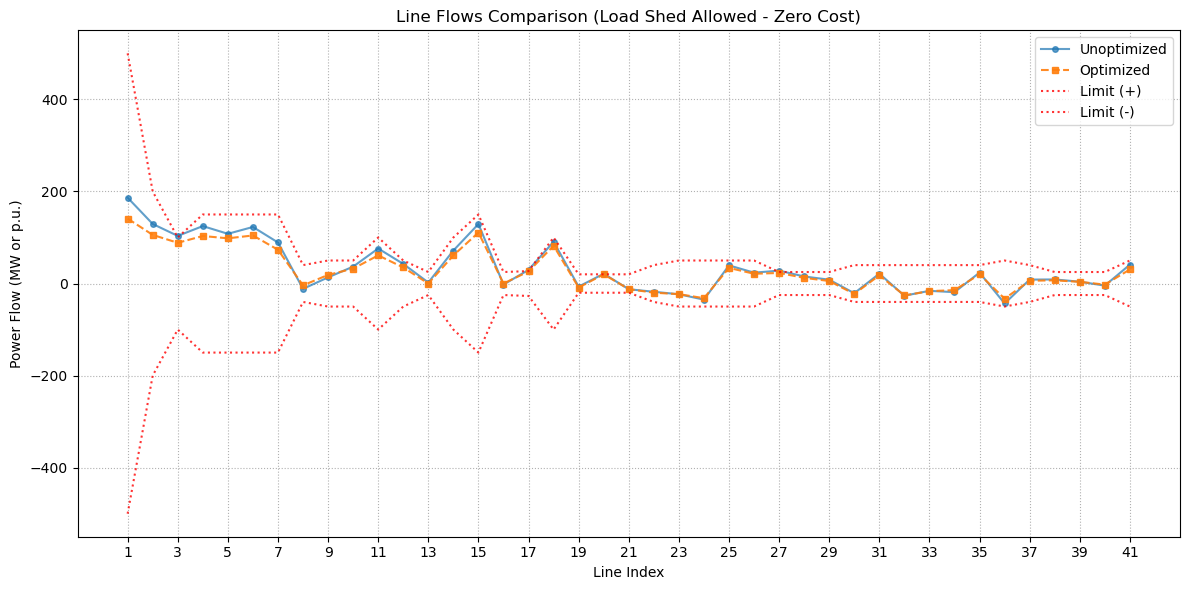

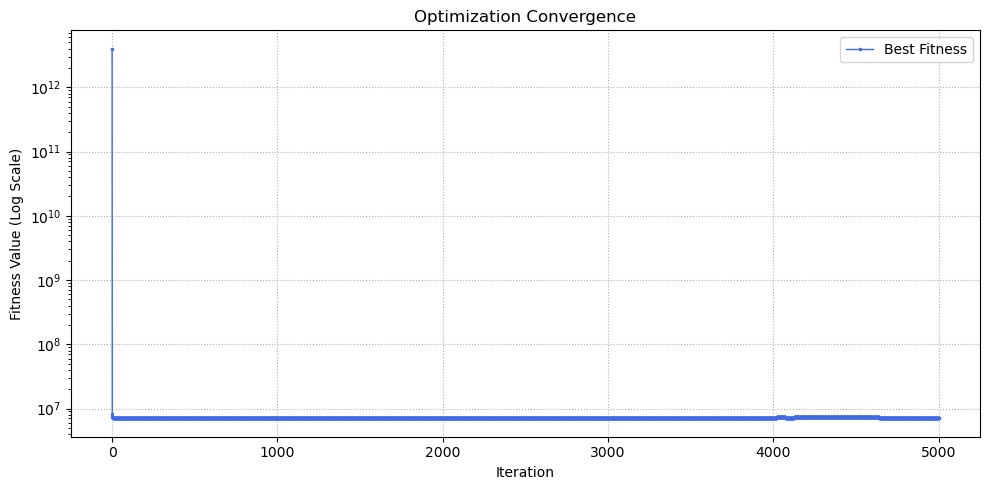

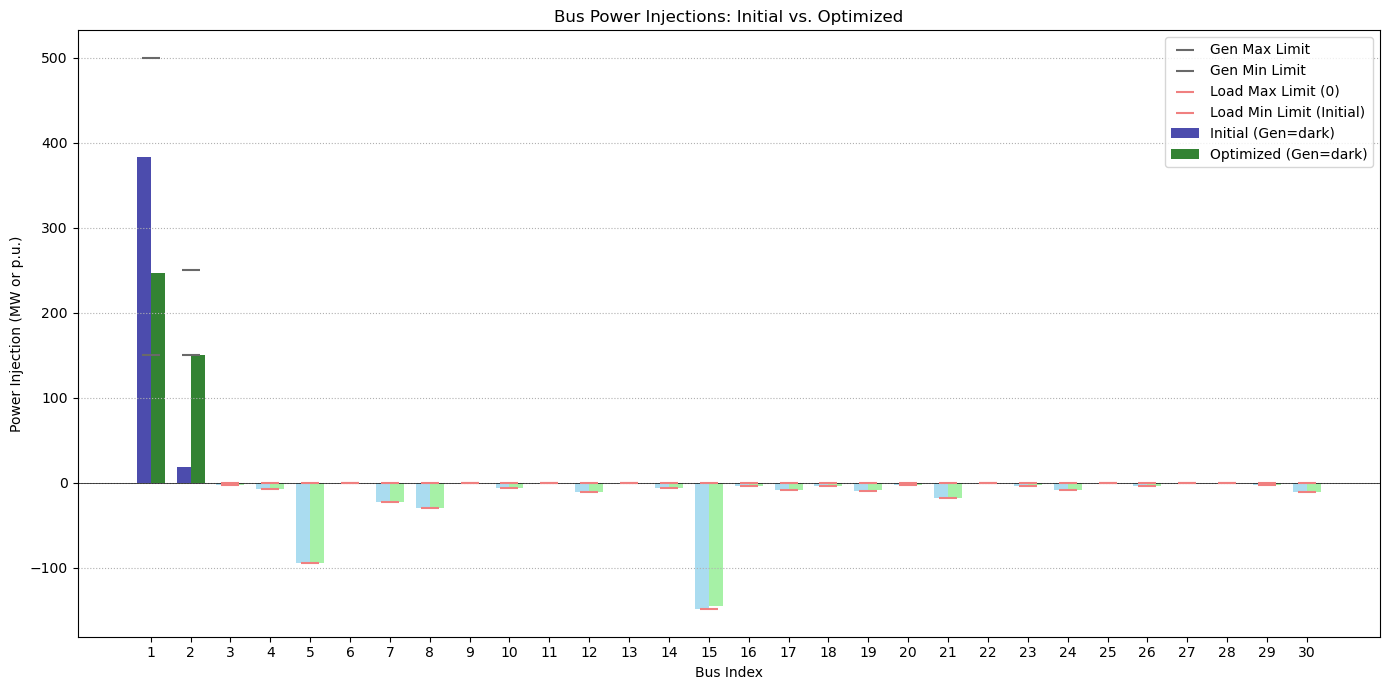

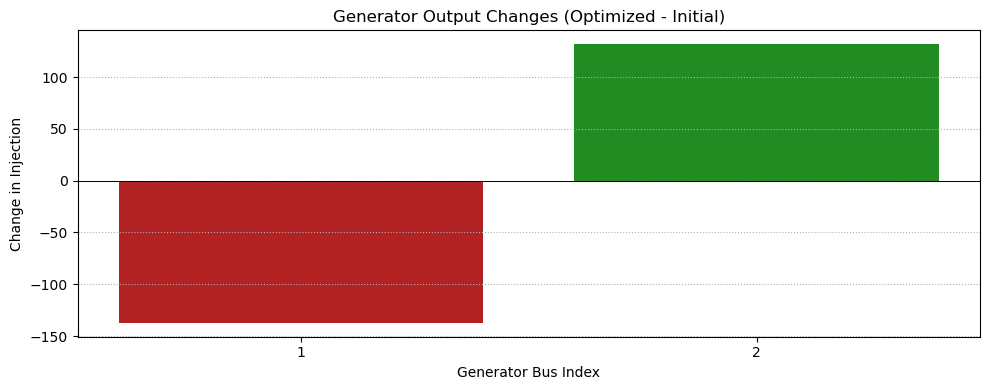

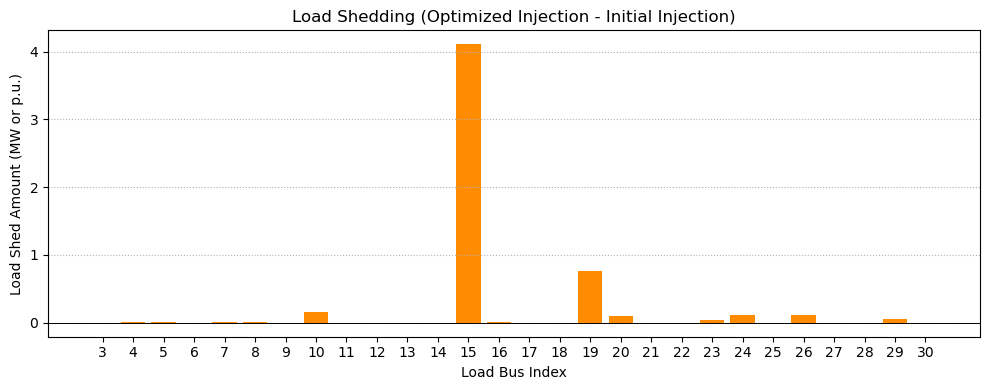


============================== RESULTS SUMMARY (Enhanced Hybrid) ==============================

Initial B:
[ 383.9   18.3   -2.4   -7.6  -94.2    0.   -22.8  -30.     0.    -5.8
    0.   -11.2    0.    -6.2 -148.7   -3.5   -9.    -3.2   -9.5   -2.2
  -17.5    0.    -3.2   -8.7    0.    -3.5    0.     0.    -2.4  -10.6]

Optimized B:
[ 246.6678  150.0005   -2.3995   -7.5929  -94.185     0.      -22.7894
  -29.9869    0.       -5.6385    0.      -11.1983    0.       -6.1979
 -144.5925   -3.4898   -8.9991   -3.1989   -8.7376   -2.1026  -17.5
    0.       -3.1531   -8.5818    0.       -3.3816    0.        0.
   -2.344   -10.5989]
Sum Optimized B: 0.000000

Initial Flows:
[186.4751 129.3871 103.4469 124.7667 107.9953 122.8583  89.1798 -11.5875
  13.401   36.7377  76.0588  42.6247   2.1928  71.6643 129.2482  -2.1928
  29.6568  90.7053  -6.6744  21.2337 -12.3704 -17.9118 -23.2898 -34.9612
  39.3968  23.5733  27.9945  15.2978   8.3318 -21.0525  21.4441 -26.4477
 -15.9057 -18.7452  23.7882 -4


Save detailed results to file? (y/n):  y
Enter filename (default: power_flow_enhanced_hybrid_results.txt):  


Attempting to save results to power_flow_enhanced_hybrid_results.txt...
Results successfully saved to power_flow_enhanced_hybrid_results.txt



Run another scenario? (y/n): n



Exiting...

Script finished.


In [9]:
# Cell 5: Main Execution Block (Modified)


if 'HybridPowerFlowOptimizer' not in globals():
    print("ERROR: Cell 2 (HybridPowerFlowOptimizer class) not executed.")
    
if 'optimize_power_flow_free_loadshed' not in globals():
    print("ERROR: Cell 3 (optimize_power_flow_free_loadshed function) not executed.")
    
if 'visualize_results' not in globals():
    print("ERROR: Cell 4 (visualize_results function) not executed.")
    


if __name__ == "__main__":

    
    matrix_file_name = 'reshaped_data.csv' 

    
    try:
        print(f"Loading system matrix A from: {matrix_file_name}")
        
        df = pd.read_csv(matrix_file_name, header=None)
        A = df.to_numpy()
        print(f"Successfully loaded matrix A with shape {A.shape}")
        if A.ndim != 2 or A.shape[0] == 0 or A.shape[1] == 0:
             raise ValueError("Loaded matrix A is not a valid 2D array.")
    except FileNotFoundError:
        print(f"FATAL ERROR: The file '{matrix_file_name}' was not found. Cannot run scenario. Exiting.")
        exit()
    except Exception as e:
        print(f"FATAL ERROR occurred while reading the matrix file '{matrix_file_name}': {e}. Exiting.")
        exit()
    

    
    num_lines_main = A.shape[0]
    num_buses_main = A.shape[1]
    print(f"System dimensions: {num_lines_main} lines, {num_buses_main} buses.")

    
    while True:
        print("\n" + "="*25 + " New Scenario (Enhanced Hybrid) " + "="*25)
        print("Objective: 1. Meet Limits & Min Gen Deviation, 2. Min Gen Cost")
        print("(Load Shedding Allowed - Zero Cost)")

        try:
            
            print(f"\n>>> Enter LINE power limits ({num_lines_main} values, e.g., space-separated):")
            while True:
                 try:
                     limits_str = input("  Line limits: ")
                     line_limits_list = [float(x) for x in limits_str.split()]
                     if len(line_limits_list) == num_lines_main:
                         line_limits_input = np.abs(np.array(line_limits_list))
                         break
                     else:
                         print(f"  Error: Expected {num_lines_main} values, got {len(line_limits_list)}. Please re-enter.")
                 except ValueError:
                     print("  Error: Invalid number format. Please enter space-separated numbers.")
                 except EOFError: raise 

            print(f"\n>>> Enter INITIAL power injections (B) for ALL buses ({num_buses_main} values):")
            print("    (Positive for Generators, Negative for Loads, e.g., space-separated)")
            while True:
                 try:
                     b_str = input("  Initial injections: ")
                     B_input_list = [float(x) for x in b_str.split()]
                     if len(B_input_list) == num_buses_main:
                         B_input = np.array(B_input_list).reshape(-1, 1)
                         break
                     else:
                         print(f"  Error: Expected {num_buses_main} values, got {len(B_input_list)}. Please re-enter.")
                 except ValueError:
                     print("  Error: Invalid number format. Please enter space-separated numbers.")
                 except EOFError: raise

            
            temp_gen_indices = np.where(B_input.flatten() > 1e-6)[0]
            temp_load_indices = np.where(B_input.flatten() <= 1e-6)[0]
            if len(temp_gen_indices) == 0:
                print("\nERROR: No Generators (positive injections) identified in initial B input! Cannot proceed.")
                continue 
            print(f"-> Identified - Gens: {temp_gen_indices+1}, Loads: {temp_load_indices+1}")

            
            gen_costs_input = np.zeros(num_buses_main)
            gen_limits_min_input = np.zeros(num_buses_main)
            gen_limits_max_input = np.zeros(num_buses_main)
            print(f"\n>>> Enter GENERATOR specific data ONLY for buses {temp_gen_indices+1}:")

            print("  Enter Gen Cost Coefficients ($/MWh):")
            for i in temp_gen_indices:
                while True:
                    try:
                        cost_str = input(f"    G{i+1} cost: ")
                        gen_costs_input[i] = float(cost_str)
                        break
                    except ValueError: print("    Invalid number. Please re-enter.")
                    except EOFError: raise

            print("  Enter Gen MIN Limit (MW):")
            for i in temp_gen_indices:
                 while True:
                    try:
                        min_str = input(f"    G{i+1} min: ")
                        gen_limits_min_input[i] = float(min_str)
                        break
                    except ValueError: print("    Invalid number. Please re-enter.")
                    except EOFError: raise

            print("  Enter Gen MAX Limit (MW):")
            for i in temp_gen_indices:
                 while True:
                    try:
                        max_str = input(f"    G{i+1} max: ")
                        gen_limits_max_input[i] = float(max_str)
                        
                        if gen_limits_max_input[i] < gen_limits_min_input[i]:
                             print(f"    Error: Max limit ({gen_limits_max_input[i]}) cannot be less than Min limit ({gen_limits_min_input[i]}). Please re-enter Max.")
                             continue 
                        break
                    except ValueError: print("    Invalid number. Please re-enter.")
                    except EOFError: raise

            
            if np.any(gen_limits_max_input[temp_gen_indices] < gen_limits_min_input[temp_gen_indices]):
                print("\nERROR: Generator Max limit is less than Min limit detected. Please restart scenario with correct inputs.")
                continue

        except EOFError:
             print("\nInput interrupted during setup. Restarting scenario...")
             continue
        except Exception as e: 
             print(f"\nAn unexpected error occurred during input: {e}. Restarting scenario...")
             continue


        
        print("\n" + "="*25 + " Running Optimization (Enhanced Hybrid) " + "="*25)
        try:
            
            opt_iterations = 5000
            opt_pop_size = 100

            start_time = time.time()
            B_optimized, fitness_history, C_optimized, C_unoptimized, final_feasible, opt_details = optimize_power_flow_free_loadshed(
                A, B_input, line_limits_input, gen_costs_input, gen_limits_min_input, gen_limits_max_input,
                iterations=opt_iterations,
                population_size=opt_pop_size
            )
            end_time = time.time()
            print(f"Optimization Duration: {end_time - start_time:.2f} seconds")

        except NameError as e:
             print(f"FATAL ERROR: Required function not defined ({e}). Make sure Cells 1-4 were executed.")
             break 
        except Exception as e:
             print(f"An unexpected error occurred during optimization run: {e}")
             
             try:
                 if input("An error occurred. Try another scenario anyway? (y/n):").strip().lower() != 'y':
                     break 
                 else:
                     continue 
             except EOFError:
                 print("\nInput interrupted. Exiting...")
                 break


        print("\n" + "="*25 + " Optimization Finished " + "="*25)


        
        try:
            viz_gen_indices = opt_details.get("gen_indices", np.array([]))
            viz_load_indices = opt_details.get("load_indices", np.array([]))
            print("\nVisualizing results...")
            visualize_results(A, B_input, B_optimized, C_optimized, C_unoptimized, line_limits_input,
                              gen_costs_input, gen_limits_min_input, gen_limits_max_input,
                              viz_gen_indices, viz_load_indices,
                              fitness_history)
        except NameError as e:
             print(f"Error during visualization: Required function not defined ({e}). Make sure Cell 4 was executed.")
        except Exception as e:
             print(f"An error occurred during visualization: {e}")


        
        if final_feasible:
            try:
                save = input("\nSave detailed results to file? (y/n): ").strip().lower()
                if save == 'y':
                    default_fname = "power_flow_enhanced_hybrid_results.txt"
                    fname = input(f"Enter filename (default: {default_fname}): ").strip() or default_fname
                    print(f"Attempting to save results to {fname}...")
                    try:
                        with open(fname, 'w') as f:
                            
                            gen_dev = 0.0; gen_cost = 0.0; load_shed = 0.0
                            gen_costs_save = []

                            if len(viz_gen_indices) > 0 and np.max(viz_gen_indices) < len(gen_costs_input):
                                gen_costs_save = gen_costs_input[viz_gen_indices]
                                dev_vec = np.abs(B_optimized.flatten()[viz_gen_indices] - B_input.flatten()[viz_gen_indices])
                                gen_dev = np.sum(dev_vec)
                                gen_cost = np.sum(gen_costs_save * dev_vec)
                            elif len(viz_gen_indices) > 0: print("Warning: Invalid gen indices for saving metrics.")

                            if len(viz_load_indices) > 0 and np.max(viz_load_indices) < len(B_optimized.flatten()):
                                shed_vec = np.maximum(0, B_optimized.flatten()[viz_load_indices] - B_input.flatten()[viz_load_indices])
                                load_shed = np.sum(shed_vec)
                            elif len(viz_load_indices) > 0: print("Warning: Invalid load indices for saving metrics.")


                            f.write("Power Flow Opt Results (Enhanced Hybrid - Load Shed Allowed - Zero Cost)\n")
                            f.write("Objective: 1. Limits & Min Deviation, 2. Min Gen Cost\n")
                            f.write("="*30+"\n\n")
                            f.write(f"Matrix A (Shape: {A.shape}):\n"); np.savetxt(f, A, fmt='%.4f'); f.write("\n")
                            f.write("Line Limits:\n"); [f.write(f"L{i+1}: {l:.2f}\n") for i,l in enumerate(line_limits_input)]
                            f.write("\nGen Costs:\n"); [f.write(f"G{viz_gen_indices[i]+1}: {c:.2f}\n") for i,c in enumerate(gen_costs_save)]
                            f.write("\nGen Min Limits:\n"); [f.write(f"G{idx+1}: {gen_limits_min_input[idx]:.2f}\n") for idx in viz_gen_indices]
                            f.write("\nGen Max Limits:\n"); [f.write(f"G{idx+1}: {gen_limits_max_input[idx]:.2f}\n") for idx in viz_gen_indices]

                            f.write("\nInitial B:\n"); [f.write(f"Bus {i+1}: {b[0]:.4f}\n") for i,b in enumerate(B_input)]
                            f.write("\nOptimized B:\n"); [f.write(f"Bus {i+1}: {b[0]:.4f}\n") for i,b in enumerate(B_optimized)]
                            f.write("\nInitial C:\n"); [f.write(f"L{i+1}: {c[0]:.4f}\n") for i,c in enumerate(C_unoptimized)]
                            f.write("\nOptimized C:\n"); [f.write(f"L{i+1}: {c[0]:.4f}\n") for i,c in enumerate(C_optimized)]
                            f.write(f"\nFinal Gen Deviation Sum: {gen_dev:.4f}\n")
                            f.write(f"Final Gen Rescheduling Cost: {gen_cost:.2f}\n")
                            f.write(f"Total Load Shed: {load_shed:.4f} MW (or p.u.)\n")
                            f.write(f"\nFeasible: {'YES' if final_feasible else 'NO'}\n")
                        print(f"Results successfully saved to {fname}")
                    except IOError as e:
                        print(f"ERROR saving results to file '{fname}': {e}")
                    except IndexError as e:
                        print(f"ERROR saving results: Index out of bounds - {e}. Check generator/load indices.")
                    except Exception as e:
                        print(f"An unexpected error occurred during saving: {e}")
            except EOFError:
                print("\nInput interrupted during save prompt.")
                
                if input("Continue to next scenario anyway? (y/n):").strip().lower() != 'y':
                    break

        elif not final_feasible:
             print("\nFinal solution was infeasible. Results not saved.")


        
        try:
            run_again = input("\nRun another scenario? (y/n):").strip().lower()
            if run_again != 'y':
                print("\nExiting...")
                break 
            else:
                print("\nRestarting scenario...\n" + "-"*70)
        except EOFError:
             print("\nInput interrupted. Exiting...")
             break 

    
    print("\nScript finished.")

